In [ ]:
import sys
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sksurv.util import Surv
import os
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from mrmr import mrmr_classif
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score, recall_score

import shap

In [2]:
# Models have been trained without feature names.
# This suppresses warnings about feature names.
import warnings
warnings.filterwarnings('ignore', message='X has feature names')

In [3]:
# SELECTION OF NEEDED PARAMETERS

# Indicate the outcome of interest
outcome = 'OS-6'

# Indicate the model to be used
file = "SVM_mrmr.joblib"

# Set this to True if you want to save figures/data, and False otherwise
save_output = True

In [4]:
# Load data
X_train = pd.read_excel("Data/X_train.xlsx").iloc[:, 1:]
X_test  = pd.read_excel("Data/X_test.xlsx").iloc[:, 1:]
X_extval = pd.read_excel("Data/X_extval.xlsx").iloc[:, 1:]

# Ensure that the order of features in train, test, and external validation sets matches
X_test = X_test[X_train.columns]
X_extval = X_extval[X_train.columns]

y_train = pd.read_excel("Data/y_train.xlsx").iloc[:, 1:]
y_test  = pd.read_excel("Data/y_test.xlsx").iloc[:, 1:]
y_extval = pd.read_excel("Data/y_extval.xlsx").iloc[:, 1:]

y_train = y_train.squeeze()
y_test = y_test.squeeze()
y_extval = y_extval.squeeze()

## Classification

In [5]:
class MRMRSelector(BaseEstimator, TransformerMixin):
    def __init__(self, K=10):
        self.K = K
        self.selected_features_ = None

    def fit(self, X, y):
        # Convert through numpy first to guarantee a clean 0-based RangeIndex on
        # both X_df and y_s. Without this, CV-sliced DataFrames keep their original
        # non-contiguous index while pd.Series(y) gets 0..n, causing mrmr's internal
        # boolean indexer to raise IndexingError on index misalignment.
        Xarr = np.array(X)
        cols = getattr(X, "columns", range(Xarr.shape[1]))
        X_df = pd.DataFrame(Xarr, columns=cols)
        y_s  = pd.Series(np.array(y).ravel())
        self.selected_features_ = mrmr_classif(X_df, y_s, K=self.K)
        return self

    def transform(self, X):
        Xarr = np.array(X)
        cols = getattr(X, "columns", range(Xarr.shape[1]))
        X_df = pd.DataFrame(Xarr, columns=cols)
        return X_df[self.selected_features_].values

In [6]:
base = file.replace(".joblib", "")
name, fs = base.rsplit("_", 1)

pipeline = joblib.load(os.path.join("Results", file))

fs_step = pipeline.named_steps.get("fs", None)
if fs != "none":
    # Get selected features - try multiple methods for compatibility
    if hasattr(fs_step, 'get_support'):
        mask = fs_step.get_support()
        feature_names = fs_step.feature_names_in_
        features_model = feature_names[mask]
    elif hasattr(fs_step, 'selected_features_'):
        # Direct access to selected features (e.g., MRMRSelector)
        features_model = np.array(fs_step.selected_features_)
    elif hasattr(fs_step, 'get_feature_names_out'):
        # For sklearn selectors that support get_feature_names_out
        features_model = fs_step.get_feature_names_out()
    else:
        raise AttributeError(f"Cannot extract selected features from {type(fs_step).__name__}")
    
    X_tr = X_train[features_model].reset_index(drop=True)
    X_te  = X_test[features_model].reset_index(drop=True)
    X_ev = X_extval[features_model].reset_index(drop=True)
    print(f"Feature selection applied — {len(features_model)} features: {features_model}")
else:
    features_model = list(X_train.columns)
    X_tr = X_train.reset_index(drop=True)
    X_te  = X_test.reset_index(drop=True)
    X_ev = X_extval.reset_index(drop=True)
    print(f"No feature selection — using all {len(features_model)} features.")

m = pipeline.named_steps.get("model", None)

Feature selection applied — 10 features: ['PLR at baseline' 'IMDC Score at baseline IO' 'KPS'
 'Platelets at baseline' 'Bone metastases' 'Hb at baseline'
 'log_NLR at baseline' 'SII at baseline' 'Nefrectomy'
 'log_Lymphocytes at baseline']


In [7]:
# Arrays of risk scores predicted by the model

y_pred_train = m.predict(X_tr)
y_pred_test = m.predict(X_te)
y_pred_extval = m.predict(X_ev)

In [8]:
def evaluate(model, X, y):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X)
        if y_proba.shape[1] == 2:
            auc = roc_auc_score(y, y_proba[:,1])
        else:
            auc = roc_auc_score(y, y_proba, multi_class="ovr")
    else:
        auc = np.nan

    return {
        "f1_weighted": f1_score(y, y_pred, average="weighted"),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "auc": auc,
        "sensitivity": recall_score(y, y_pred),
        "specificity": recall_score(y, y_pred, pos_label=0)
    }

In [9]:
# Evaluation
extval_scores  = evaluate(m, X_ev,  y_extval)

print(f"External validation:\n")
print(f"  - F1-score (weighted): {extval_scores['f1_weighted']:.4f}")
print(f"  - Balanced accuracy: {extval_scores['balanced_accuracy']:.4f}")
print(f"  - AUC: {extval_scores['auc']:.4f}")
print(f"  - Sensitivity: {extval_scores['sensitivity']:.4f}")
print(f"  - Specificity: {extval_scores['specificity']:.4f}")

External validation:

  - F1-score (weighted): 0.7742
  - Balanced accuracy: 0.6028
  - AUC: 0.6556
  - Sensitivity: 0.9556
  - Specificity: 0.2500


## Explainability

In [10]:
# Load dataset for explainability
X_extval_expl = pd.read_excel('Data/X_extval_expl.xlsx')

# Load explainer
explainer = pickle.load(open(f'Explainability/explainer.pkl', 'rb'))

In [11]:
# Compute shap values for external validation set
shap_values = explainer(X_ev)

# Link shap values to original data
features_original = np.array([n.removeprefix('log_') for n in features_model])
X_extval_expl = X_extval_expl.loc[:,features_original]
for i, c in enumerate(features_original):
    shap_values.feature_names[i] = c
shap_values.data = X_extval_expl.values

# Save shap values
if save_output:
    os.makedirs("Extval", exist_ok=True)
    with open(f'Extval/shap_values_{name}{fs}_extval.pkl', 'wb') as f:
        pickle.dump(shap_values, f)

ExactExplainer explainer: 58it [00:38,  1.40it/s]                        


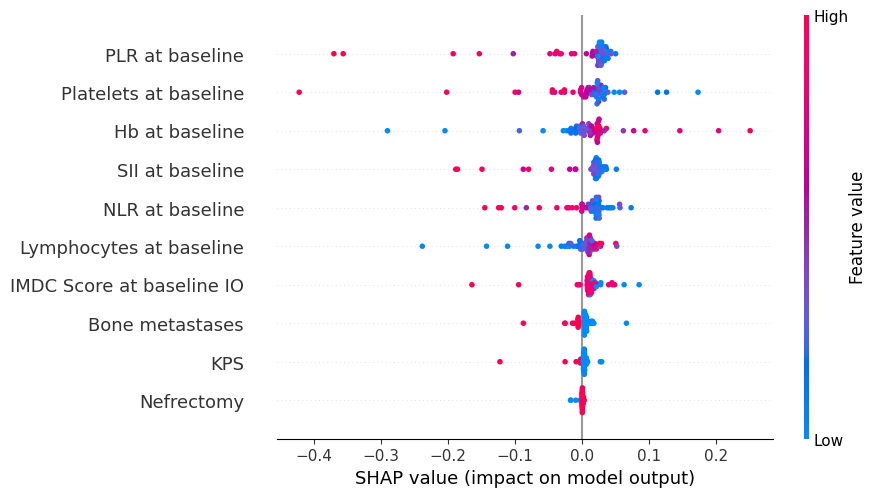

In [12]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=X_ev.shape[1], show=False)

if save_output:
    plt.savefig(f'Extval/Beeswarm_{name}{fs}_complete.png', format='png', dpi=300, bbox_inches='tight')

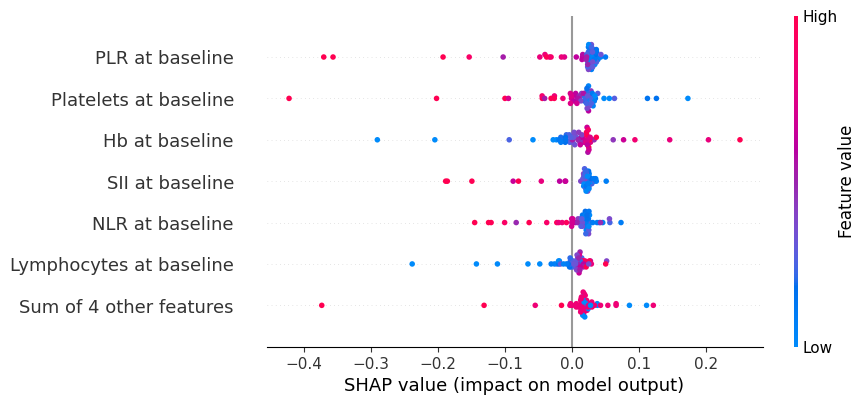

In [13]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=7, show=False)

if save_output:
    plt.savefig(f'Extval/Beeswarm_{name}{fs}_reduced.png', format='png', dpi=300, bbox_inches='tight')